<a href="https://colab.research.google.com/github/ahmad0719/cal/blob/main/fake_news_detection_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection using NLP

**Objective:** Build an end-to-end machine learning pipeline for Fake News Detection, with **precision as the primary optimization metric** so legitimate news articles are less likely to be incorrectly flagged as fake.

This notebook uses the uploaded `fake_or_real_news.csv` dataset and includes:
- Dataset exploration and data-quality checks
- Fake vs. real distribution and word clouds
- NLP preprocessing: lowercasing, punctuation/numbers/special-character removal, stopword removal, emoji/chat-word normalization, and lemmatization
- TF-IDF feature engineering
- Five classifiers: Logistic Regression, Multinomial Naive Bayes, Decision Tree, Random Forest, and Gradient Boosting
- Accuracy, **precision**, recall, and confusion matrices
- Precision-sorted comparison table
- Accuracy and precision comparison charts
- A final precision-focused interpretation and best-model selection


## 1. Install / import required libraries

In [2]:
# Google Colab-compatible setup
!pip -q install wordcloud scikit-learn pandas matplotlib xgboost

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
print('Libraries imported successfully.')


Libraries imported successfully.


## 2. Load the uploaded dataset

In [3]:
# Look for the supplied CSV in common Colab/local locations.
possible_paths = [
    Path('/mnt/data/fake_or_real_news.csv'),
    Path('/content/fake_or_real_news.csv'),
    Path('fake_or_real_news.csv')
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

# If the file is not present, offer a standard Google Colab upload dialog.
if DATA_PATH is None:
    try:
        from google.colab import files
        print('fake_or_real_news.csv not found. Please upload the CSV using the dialog below.')
        uploaded = files.upload()
        csv_names = [name for name in uploaded if name.lower().endswith('.csv')]
        if not csv_names:
            raise FileNotFoundError('No CSV file was uploaded.')
        DATA_PATH = Path('/content') / csv_names[0]
    except ImportError:
        raise FileNotFoundError(
            'fake_or_real_news.csv was not found. Place the CSV next to this notebook and rerun the cell.'
        )

df = pd.read_csv(DATA_PATH)
print(f'Dataset path: {DATA_PATH}')
print(f'Shape: {df.shape}')
display(df.head())


fake_or_real_news.csv not found. Please upload the CSV using the dialog below.


Saving fake_or_real_news.csv to fake_or_real_news.csv
Dataset path: /content/fake_or_real_news.csv
Shape: (6335, 4)


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Isla...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Political Suicide At A Trump Rally (VIDEO),Google Pinterest Digg Linkedin Reddit Stumbleupon Print Delicious Pocket Tumblr \nThere are two fundamental truths i...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,"U.S. Secretary of State John F. Kerry said Monday that he will stop in Paris later this week, amid criticism that no...",REAL
3,10142,Bernie supporters on Twitter erupt in anger against the DNC: 'We tried to warn you!',"— Kaydee King (@KaydeeKing) November 9, 2016 The lesson from tonight's Dem losses: Time for Democrats to start liste...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners Hillary Clinton and Donald Trump are leading in the polls.\n\nTrump i...,REAL


## 3. Explore shape, columns, missing values, and duplicates

In [4]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
display(df.isna().sum().to_frame('missing_count'))

print('Duplicate rows:', df.duplicated().sum())
print('Duplicate articles by title + text:', df.duplicated(subset=['title', 'text']).sum())

print('\nLabel counts:')
display(df['label'].value_counts().to_frame('count'))


Shape: (6335, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Data types:
Unnamed: 0     int64
title         object
text          object
label         object
dtype: object

Missing values:


,missing_count
Unnamed: 0,0
title,0
text,0
label,0


Duplicate rows: 0
Duplicate articles by title + text: 29

Label counts:


,count
label,
REAL,3171
FAKE,3164


### Dataset-specific observations
The uploaded dataset contains 6,335 rows and the columns `Unnamed: 0`, `title`, `text`, and `label`. The target has two classes: `FAKE` and `REAL`. The index-like `Unnamed: 0` column is not used as a predictive feature.


## 4. Clean the dataset and create the model text

In [5]:
# Keep only the fields required for text classification
model_df = df[['title', 'text', 'label']].copy()
model_df['title'] = model_df['title'].fillna('')
model_df['text'] = model_df['text'].fillna('')
model_df['label'] = model_df['label'].astype(str).str.upper().str.strip()

# Combine title + article body because titles can contain strong predictive information
model_df['raw_text'] = (model_df['title'].str.strip() + ' ' + model_df['text'].str.strip()).str.strip()

# Remove completely empty articles and duplicate title+text pairs
model_df = model_df[model_df['raw_text'].str.strip().ne('')].copy()
model_df = model_df.drop_duplicates(subset=['title', 'text']).reset_index(drop=True)

print('Usable rows after cleaning:', len(model_df))
print(model_df['label'].value_counts())


Usable rows after cleaning: 6306
label
REAL    3154
FAKE    3152
Name: count, dtype: int64


## 5. Visualize fake vs. real distribution

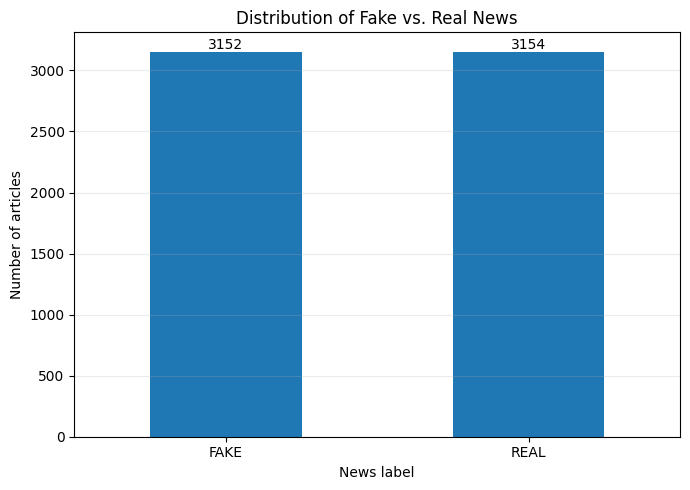

Percentage distribution:


,percentage
label,
FAKE,49.98
REAL,50.02


In [6]:
label_counts = model_df['label'].value_counts().reindex(['FAKE', 'REAL'])

plt.figure(figsize=(7, 5))
ax = label_counts.plot(kind='bar')
plt.title('Distribution of Fake vs. Real News')
plt.xlabel('News label')
plt.ylabel('Number of articles')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.show()

print('Percentage distribution:')
display((label_counts / label_counts.sum() * 100).round(2).to_frame('percentage'))


## 6. NLP preprocessing

In [7]:
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

# Common chat/text abbreviations and contractions frequently found in web text.
CHAT_WORDS = {
    'u': 'you', 'ur': 'your', 'r': 'are', 'pls': 'please', 'plz': 'please',
    'btw': 'by the way', 'imo': 'in my opinion', 'imho': 'in my humble opinion',
    'idk': 'i do not know', 'dont': 'do not', 'cant': 'cannot', 'wont': 'will not',
    'isnt': 'is not', 'arent': 'are not', 'wasnt': 'was not', 'werent': 'were not',
    'youre': 'you are', 'theyre': 'they are', 'weve': 'we have', 'ive': 'i have'
}

EMOJI_RE = re.compile(
    '['
    u'\U0001F300-\U0001F5FF'
    u'\U0001F600-\U0001F64F'
    u'\U0001F680-\U0001F6FF'
    u'\U0001F700-\U0001F77F'
    u'\U0001F780-\U0001F7FF'
    u'\U0001F800-\U0001F8FF'
    u'\U0001F900-\U0001F9FF'
    u'\U0001FA00-\U0001FAFF'
    u'\u2600-\u26FF'
    u'\u2700-\u27BF'
    ']+', flags=re.UNICODE)

def expand_chat_words(text):
    tokens = text.split()
    return ' '.join(CHAT_WORDS.get(tok, tok) for tok in tokens)

def clean_text(text):
    text = str(text).lower()
    # Handling emojis: remove them because the model uses word-level TF-IDF features.
    text = EMOJI_RE.sub(' ', text)
    text = text.replace('&amp;', ' and ')
    text = re.sub(r"https?://\S+|www\.\S+", ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r"([a-z]+)'ll\b", r'\1 will', text)
    text = re.sub(r"([a-z]+)'re\b", r'\1 are', text)
    text = re.sub(r"([a-z]+)'ve\b", r'\1 have', text)
    text = re.sub(r"([a-z]+)n't\b", r'\1 not', text)
    text = expand_chat_words(text)
    # Remove numbers, punctuation and other special characters.
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    # Stemming satisfies the assignment's stemming-or-lemmatization requirement.
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Preview before/after cleaning
sample = model_df['raw_text'].iloc[0]
print('Original text preview:\n', sample[:700])
print('\nCleaned text preview:\n', clean_text(sample)[:700])


Original text preview:
 You Can Smell Hillary’s Fear Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. 
The word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. 
But that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. 
The FBI is under attack by everyon

Cleaned text preview:
 smell hillari fear daniel greenfield shillman journal fellow freedom center new york writer focus radic islam final stretch elect hillari rodham clinton gone war fbi word unpreced thrown elect ought retir unpreced nomine major polit parti war fbi exac

In [8]:
model_df['clean_text'] = model_df['raw_text'].map(clean_text)
model_df = model_df[model_df['clean_text'].str.len().gt(0)].reset_index(drop=True)

print('After preprocessing:', model_df.shape)
display(model_df[['title', 'label', 'clean_text']].head(3))


After preprocessing: (6306, 5)


,title,label,clean_text
0,You Can Smell Hillary’s Fear,FAKE,smell hillari fear daniel greenfield shillman journal fellow freedom center new york writer focus radic islam final ...
1,Watch The Exact Moment Paul Ryan Committed Political Suicide At A Trump Rally (VIDEO),FAKE,watch exact moment paul ryan commit polit suicid trump ralli video googl pinterest digg linkedin reddit stumbleupon ...
2,Kerry to go to Paris in gesture of sympathy,REAL,kerri pari gestur sympathi secretari state john kerri said monday stop pari later week amid critic american offici a...


## 7. Word clouds for FAKE and REAL news

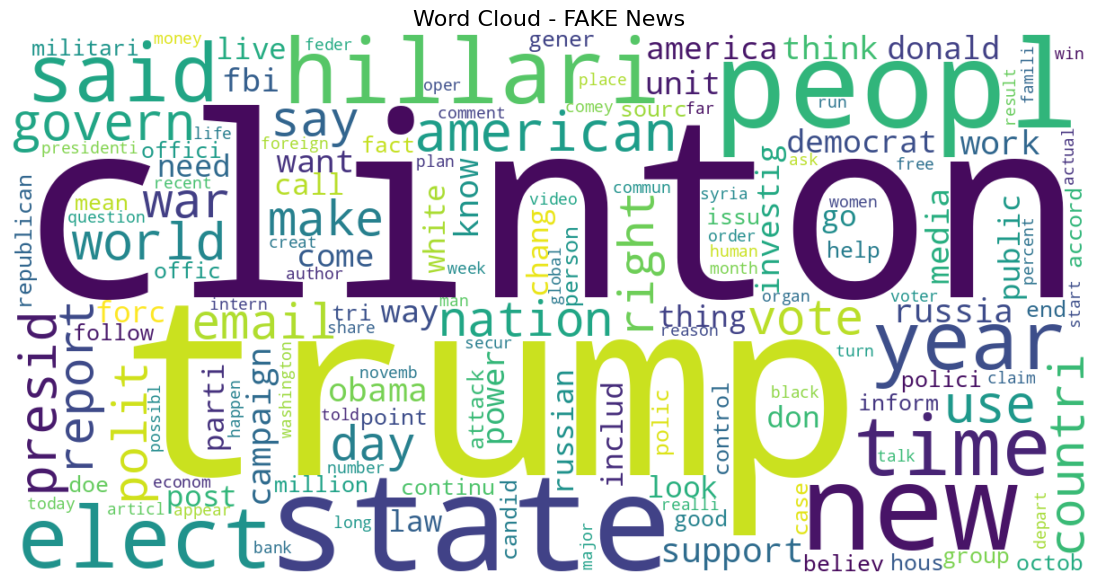

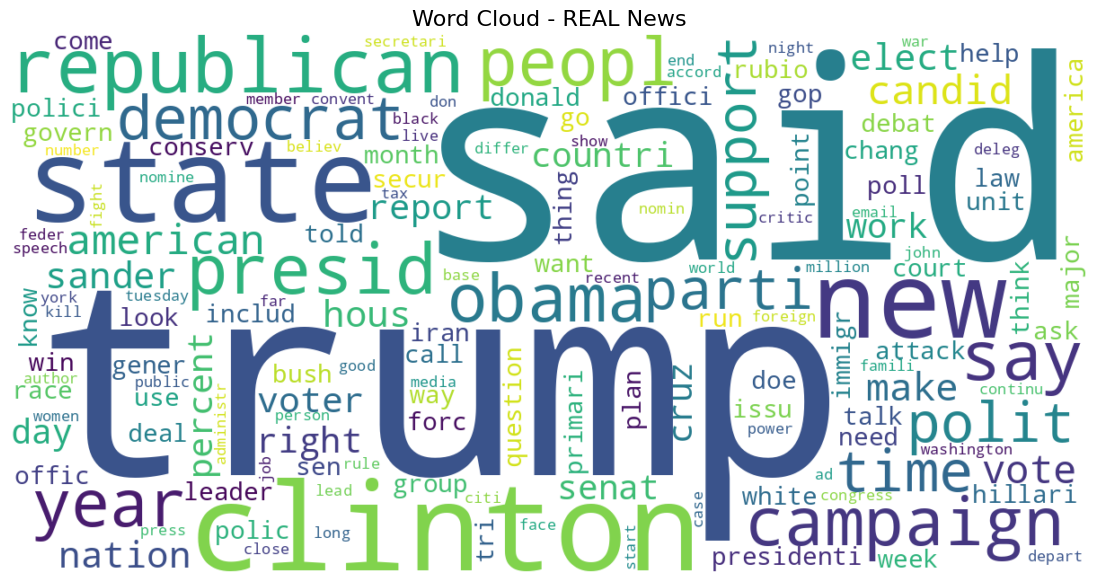

In [9]:
def make_wordcloud(texts, title):
    text_blob = ' '.join(texts)
    wc = WordCloud(width=1200, height=600, background_color='white', max_words=150, collocations=False).generate(text_blob)
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

make_wordcloud(model_df.loc[model_df['label'] == 'FAKE', 'clean_text'], 'Word Cloud - FAKE News')
make_wordcloud(model_df.loc[model_df['label'] == 'REAL', 'clean_text'], 'Word Cloud - REAL News')


## 8. Train/test split
A stratified split preserves the fake/real class balance. The TF-IDF vectorizer is fitted **only on the training set** to prevent test-set information leakage.


In [10]:
X = model_df['clean_text']
y = model_df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training samples:', len(X_train_text))
print('Testing samples:', len(X_test_text))
print('Training label distribution:')
print(y_train.value_counts(normalize=True).round(3))


Training samples: 5044
Testing samples: 1262
Training label distribution:
label
REAL    0.5
FAKE    0.5
Name: proportion, dtype: float64


## 9. TF-IDF feature engineering

In [11]:
tfidf = TfidfVectorizer(
    lowercase=False,          # text is already lowercased
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print('TF-IDF training matrix:', X_train.shape)
print('TF-IDF test matrix:', X_test.shape)
print('Vocabulary size:', len(tfidf.vocabulary_))


TF-IDF training matrix: (5044, 30000)
TF-IDF test matrix: (1262, 30000)
Vocabulary size: 30000


## 10. Train five machine-learning models

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', C=2.0, solver='liblinear', random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'Decision Tree': DecisionTreeClassifier(max_depth=30, min_samples_leaf=2, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=None, min_samples_leaf=1, class_weight='balanced', n_jobs=-1, random_state=42),
    'Gradient Boosting / XGBoost': XGBClassifier(n_estimators=120, max_depth=5, learning_rate=0.08, subsample=0.85, colsample_bytree=0.7, eval_metric='logloss', tree_method='hist', n_jobs=-1, random_state=42)
}

results = []
predictions = {}
conf_matrices = {}

# Encode labels to numerical for models that require it (like XGBoost)
# Map 'FAKE' to 1 and 'REAL' to 0, as 'FAKE' is the positive class for precision optimization
y_train_encoded = y_train.replace({'FAKE': 1, 'REAL': 0})
y_test_encoded = y_test.replace({'FAKE': 1, 'REAL': 0})

# Define the numerical labels for confusion matrix and metrics, consistent with encoding
encoded_labels = [1, 0] # FAKE (1) then REAL (0)
positive_class_encoded = 1 # FAKE

for name, model in models.items():
    print(f'Training {name}...')
    # Use the encoded y_train for fitting
    model.fit(X_train, y_train_encoded)
    # The predict method will output encoded labels (0 or 1)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    # Use encoded labels for confusion matrix
    conf_matrices[name] = confusion_matrix(y_test_encoded, y_pred, labels=encoded_labels)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'Precision': precision_score(y_test_encoded, y_pred, pos_label=positive_class_encoded, zero_division=0),
        'Recall': recall_score(y_test_encoded, y_pred, pos_label=positive_class_encoded, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values('Precision', ascending=False).reset_index(drop=True)
results_df

Training Logistic Regression...
Training Naive Bayes...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting / XGBoost...


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.923930,0.914729,0.935024
1,Random Forest,0.904913,0.896124,0.916006
2,Naive Bayes,0.904120,0.887538,0.925515
3,Gradient Boosting / XGBoost,0.900158,0.885496,0.919176
4,Decision Tree,0.773376,0.767442,0.784469


### Metric definition used for precision optimization
Here, **FAKE is treated as the positive class**. Therefore, precision answers: *Of the articles the model flagged as FAKE, what proportion were actually FAKE?* High precision means fewer legitimate (REAL) articles are wrongly flagged as fake, matching the assignment objective.


## 11. Detailed evaluation: accuracy, precision, recall, and confusion matrices

In [13]:
print('Results sorted by precision (FAKE as positive class):')
display(results_df.style.format({'Accuracy':'{:.4f}', 'Precision':'{:.4f}', 'Recall':'{:.4f}'}))

for name in results_df['Model']:
    y_pred = predictions[name]
    print('\n' + '=' * 80)
    print(name)
    print('=' * 80)
    print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred, pos_label="FAKE", zero_division=0):.4f}')
    print(f'Recall   : {recall_score(y_test, y_pred, pos_label="FAKE", zero_division=0):.4f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, labels=['FAKE', 'REAL'], zero_division=0))

    cm = conf_matrices[name]
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1], ['FAKE', 'REAL'])
    ax.set_yticks([0, 1], ['FAKE', 'REAL'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


Results sorted by precision (FAKE as positive class):


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.9239,0.9147,0.9350
1,Random Forest,0.9049,0.8961,0.9160
2,Naive Bayes,0.9041,0.8875,0.9255
3,Gradient Boosting / XGBoost,0.9002,0.8855,0.9192
4,Decision Tree,0.7734,0.7674,0.7845



Logistic Regression


TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['FAKE' 'REAL'] and y_pred=[0 1]. Make sure that the predictions provided by the classifier coincides with the true labels.

## 12. Comparison table sorted by precision

In [ ]:
comparison = results_df.copy()
comparison['Accuracy (%)'] = comparison['Accuracy'] * 100
comparison['Precision (%)'] = comparison['Precision'] * 100
comparison['Recall (%)'] = comparison['Recall'] * 100
comparison = comparison[['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)']]

display(comparison.style.format({
    'Accuracy (%)': '{:.2f}',
    'Precision (%)': '{:.2f}',
    'Recall (%)': '{:.2f}'
}))

top_model = results_df.iloc[0]['Model']
top_precision = results_df.iloc[0]['Precision']
print(f'Top precision performer: {top_model} ({top_precision:.4f})')


## 13. Visual comparison of accuracy and precision

In [ ]:
plot_df = results_df.set_index('Model')

plt.figure(figsize=(10, 5))
ax = plot_df['Accuracy'].plot(kind='bar')
plt.title('Model Comparison - Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
ax = plot_df['Precision'].plot(kind='bar')
plt.title('Model Comparison - Precision (FAKE as Positive Class)')
plt.ylabel('Precision')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()


## 14. Precision-focused conclusion
**Primary selection criterion:** precision for the `FAKE` class. The winning model is the model ranked first in the precision-sorted results table. This aligns with the assignment's objective of minimizing false positives—legitimate (`REAL`) news articles incorrectly flagged as fake.

When interpreting the final table, compare precision first, then use recall and accuracy as secondary checks. A model with slightly lower overall accuracy can still be preferable for this task if its precision is higher and therefore its false-positive rate for the FAKE prediction is better controlled.


In [ ]:
best = results_df.iloc[0]
print('FINAL MODEL SELECTION')
print('-' * 50)
print('Model    :', best['Model'])
print(f'Accuracy : {best["Accuracy"]:.4f}')
print(f'Precision: {best["Precision"]:.4f}')
print(f'Recall   : {best["Recall"]:.4f}')
print('\nReason: Precision is the assignment\'s focus metric, with FAKE treated as the positive class.')


## 15. Optional: save the results table
The next cell exports the precision-sorted comparison table so it can be submitted or reused in a report.


In [ ]:
comparison.to_csv('fake_news_model_comparison.csv', index=False)
print('Saved: fake_news_model_comparison.csv')
